In [1]:
import pandas as pd

df = pd.read_csv("/content/Pharma_Industry.csv")
df.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


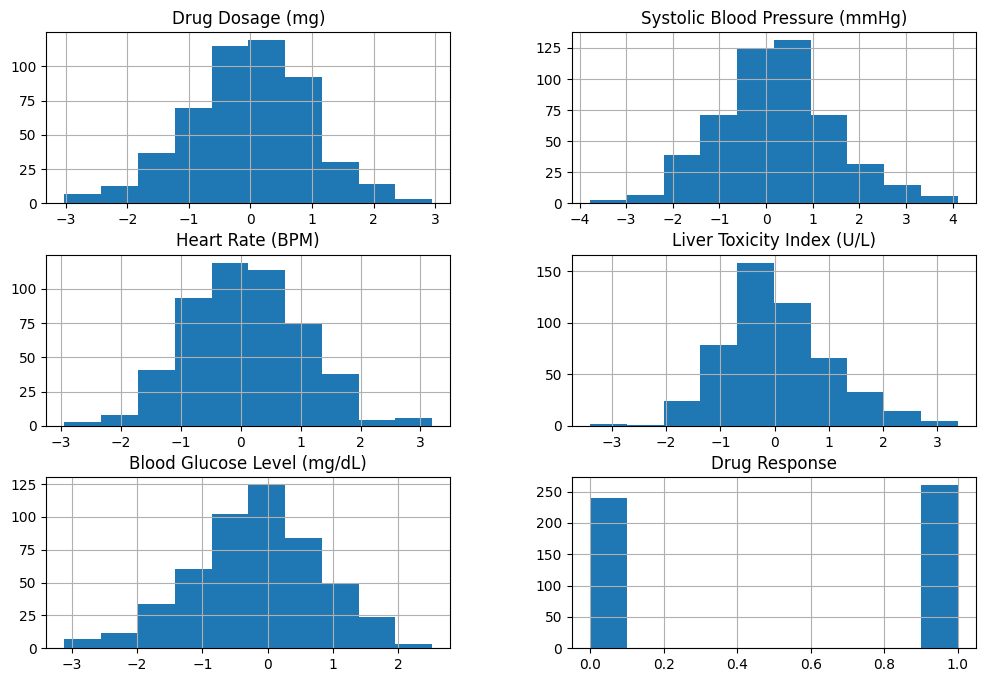

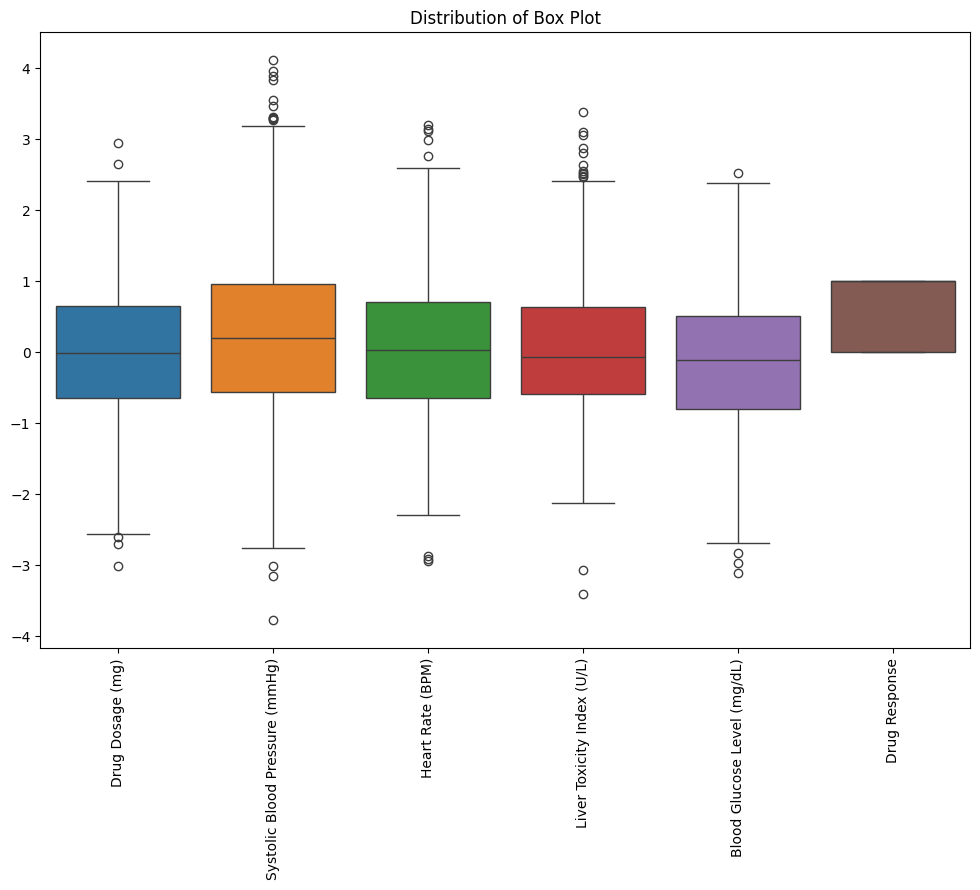

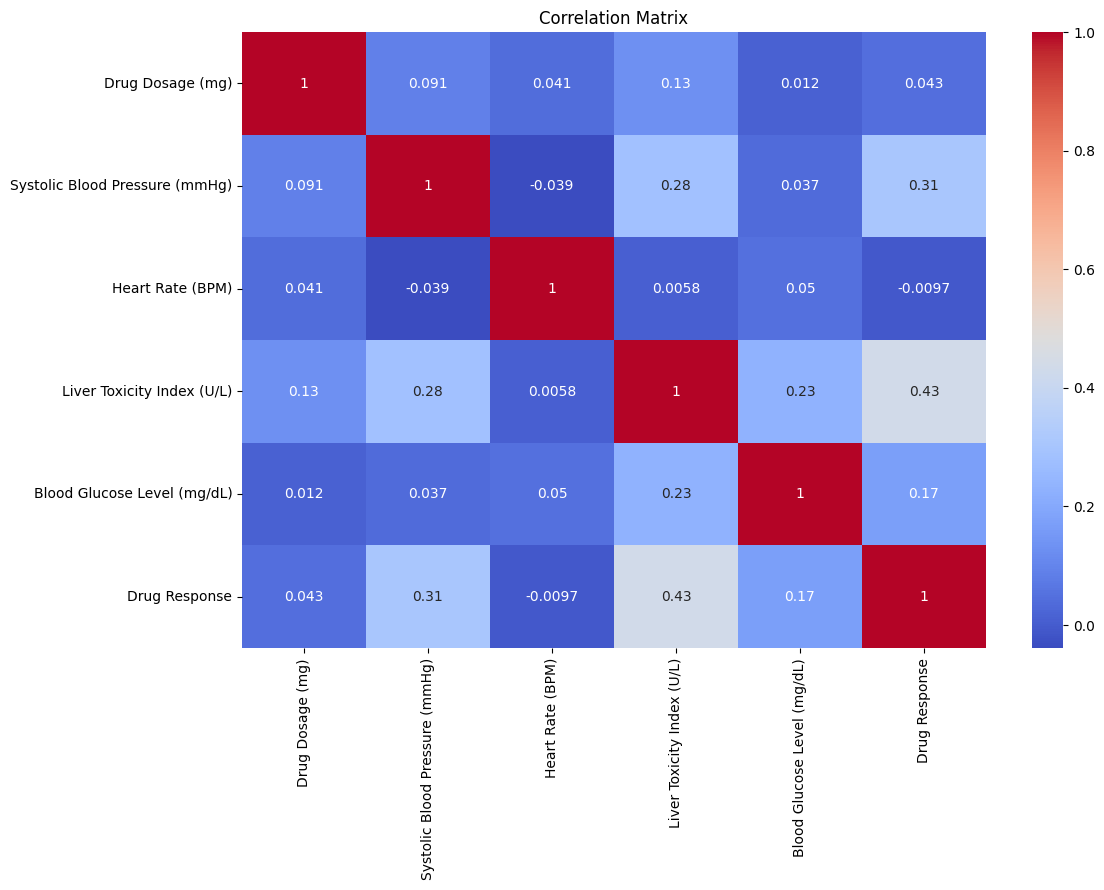

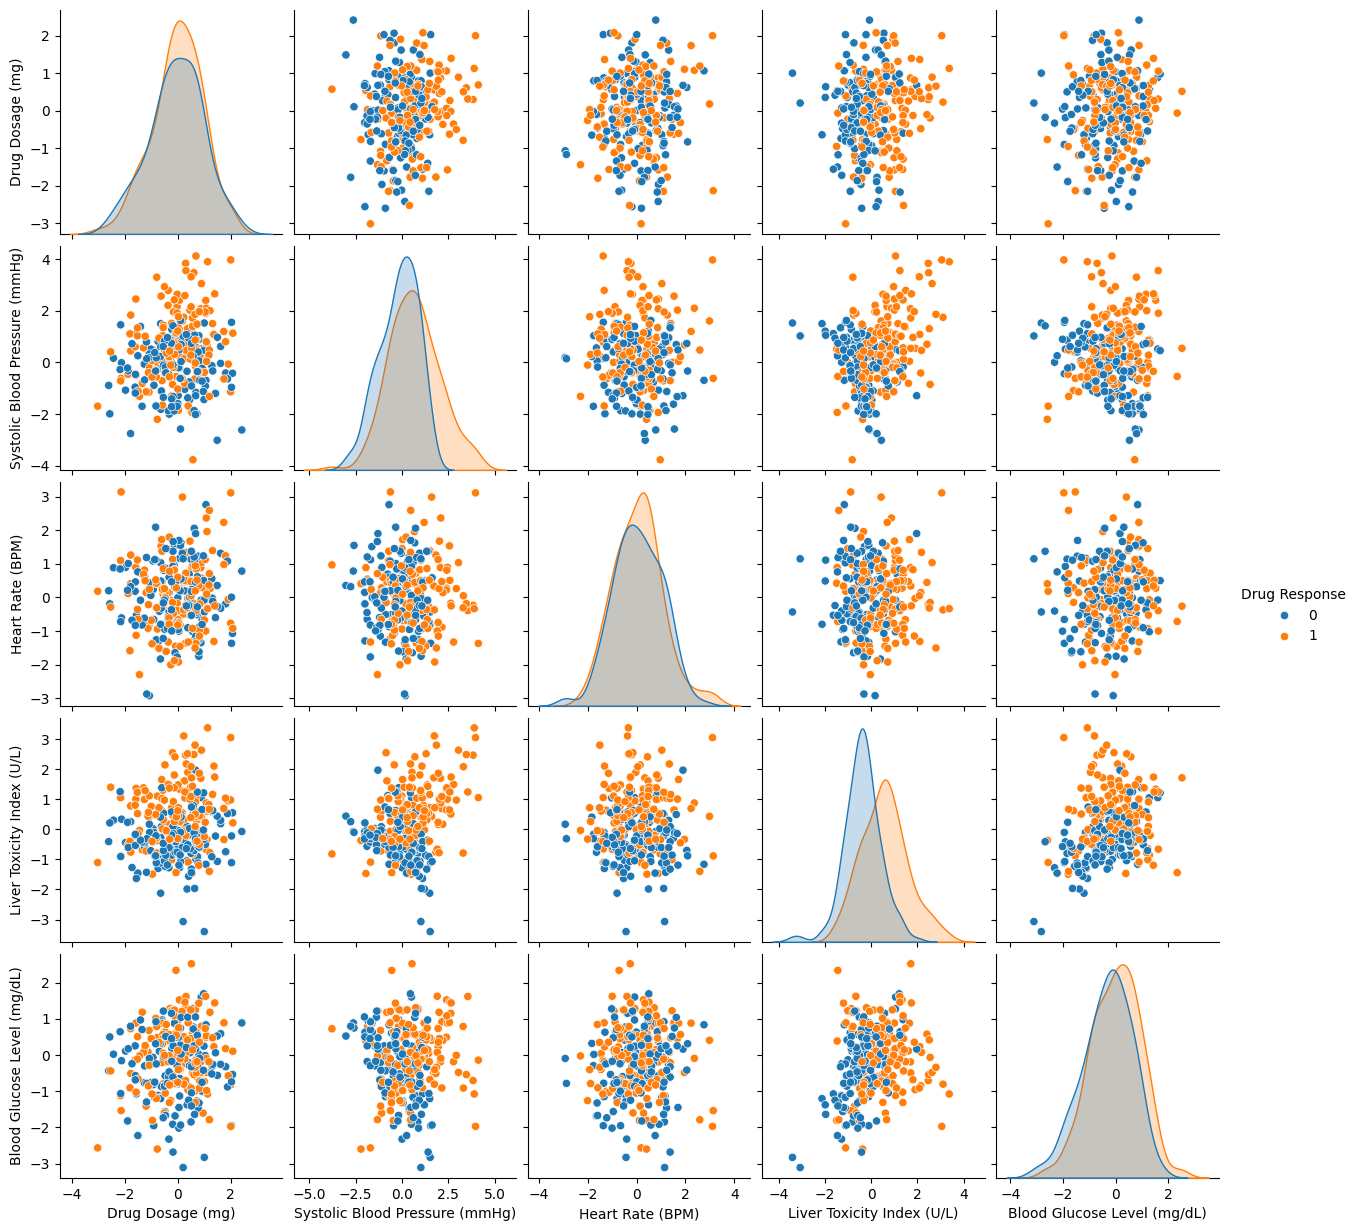

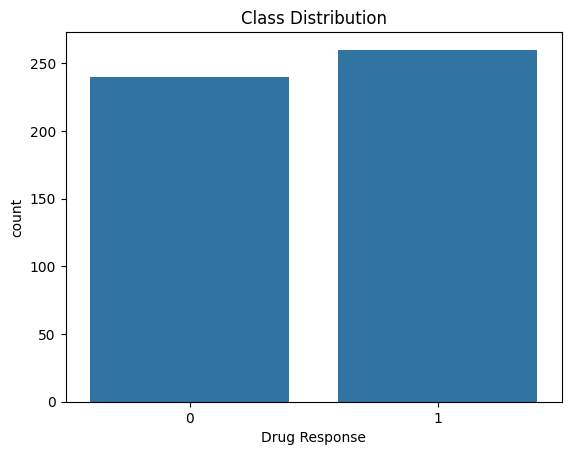

LINEAR SVM RESULTS

              precision    recall  f1-score   support

           0       0.69      0.77      0.73        48
           1       0.76      0.67      0.71        52

    accuracy                           0.72       100
   macro avg       0.72      0.72      0.72       100
weighted avg       0.72      0.72      0.72       100



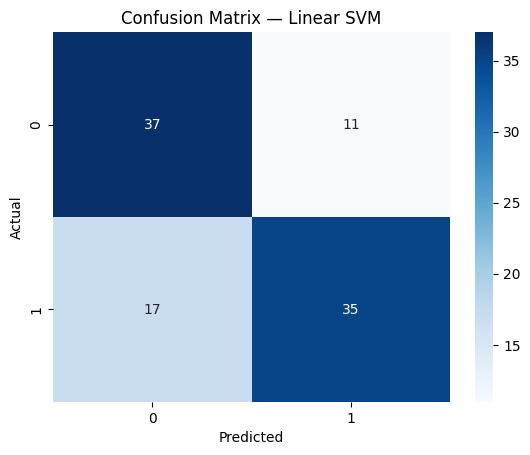

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


,Accuracy,F1
linear,0.72,0.714286
rbf,0.77,0.788991
poly,0.66,0.673077


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
df=pd.read_csv(r"/content/Pharma_Industry.csv")

df.info()

df.describe()

df.head()

df.isnull().sum()

import matplotlib.pyplot as plt
import seaborn as sns

df.hist(figsize=(12,8))
plt.show()

plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.title("Distribution of Box Plot")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,8))
plt.title("Correlation Matrix")
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sns.pairplot(df.sample(300), hue="Drug Response")
plt.show()

sns.countplot(x=df["Drug Response"])
plt.title("Class Distribution")
plt.show()

svm_linear = SVC(kernel="linear")
svm_linear.fit(X_train, y_train)
y_pred = svm_linear.predict(X_test)
print("LINEAR SVM RESULTS\n")
print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test,y_pred),annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Linear SVM")
plt.show()

param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf", "poly"],
    "gamma": ["scale", 0.1, 0.01]
}
grid = GridSearchCV(SVC(), param_grid,
                    cv=5,
                    scoring="f1",
                    n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)

kernels = ["linear", "rbf", "poly"]
results = {}
for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results[k] = {
        "Accuracy": accuracy_score(y_test,preds),
        "F1": f1_score(y_test,preds)
    }
pd.DataFrame(results).T

In [4]:
'''
The SVM model performed effectively after proper preprocessing and parameter tuning.
It demonstrated strong classification capability and generalization performance.
While computationally intensive and less interpretable,
SVM is highly suitable for complex datasets with non-linear boundaries.

The implementation of SVM, combined with feature scaling and hyperparameter tuning, resulted in a robust classification model.
The strengths of SVM in handling high-dimensional data and maximizing margin make it a powerful algorithm.
However, its computational complexity and sensitivity to parameters must be carefully managed in practical applications.
'''

'\nThe SVM model performed effectively after proper preprocessing and parameter tuning. \nIt demonstrated strong classification capability and generalization performance. \nWhile computationally intensive and less interpretable, \nSVM is highly suitable for complex datasets with non-linear boundaries.\n\nThe implementation of SVM, combined with feature scaling and hyperparameter tuning, resulted in a robust classification model. \nThe strengths of SVM in handling high-dimensional data and maximizing margin make it a powerful algorithm.\nHowever, its computational complexity and sensitivity to parameters must be carefully managed in practical applications.\n'